In [1]:
# 데이터 분석 및 시각화에 필요한 기본 라이브러리들을 불러옵니다.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn 라이브러리에서 필요한 모듈들을 불러옵니다.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# TensorFlow Keras 라이브러리를 불러옵니다.
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

1.

In [2]:
from sklearn.metrics import confusion_matrix

2.

In [3]:
churn_df = pd.read_csv('10_customer_churn.csv')

3.

<Axes: xlabel='monthly_charge', ylabel='Count'>

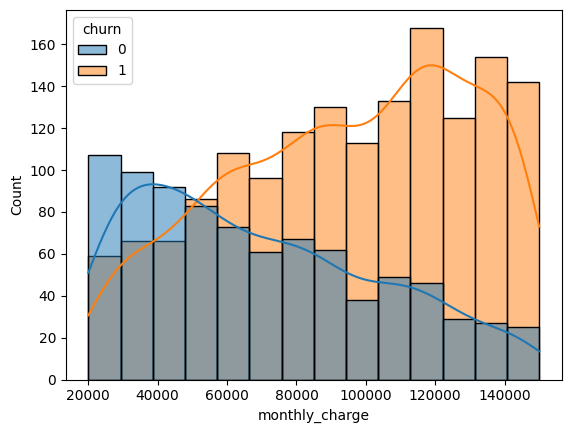

In [5]:
sns.histplot(data=churn_df, x='monthly_charge', hue='churn', kde=True)

In [ ]:
답안03 = '2'

4.

In [8]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import urllib.request

# 1. 인터넷에서 나눔고딕 폰트 파일을 현재 폴더로 직접 다운로드
font_url = "https://github.com/google/fonts/raw/main/ofl/nanumgothic/NanumGothic-Regular.ttf"
urllib.request.urlretrieve(font_url, "my_nanum_font.ttf")

# 2. 다운로드한 폰트 파일의 경로 지정 및 이름 속성 가져오기
fe = fm.FontEntry(fname="my_nanum_font.ttf", name="MyNanum")
fm.fontManager.ttflist.insert(0, fe)  # Matplotlib 폰트 리스트 맨 앞에 강제 주입

# 3. 주입한 폰트 이름으로 전역 설정 변경 (마이너스 깨짐 방지도 함께)
plt.rc('font', family='MyNanum')
plt.rcParams['axes.unicode_minus'] = False

<Axes: xlabel='contract_type', ylabel='count'>

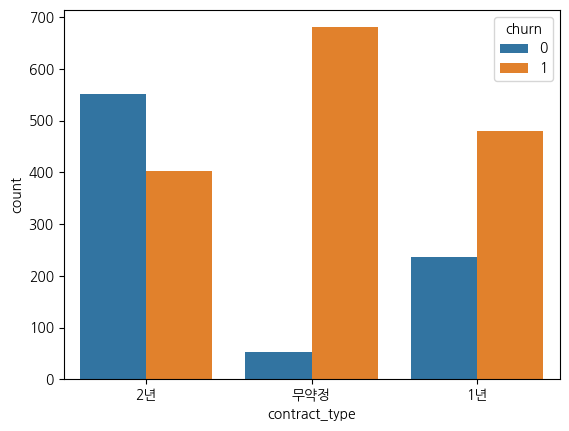

In [9]:
sns.countplot(data=churn_df, x='contract_type', hue='churn')

5.

In [10]:
churn_df.groupby(['churn'])[['tenure_months', 'monthly_charge', 'support_calls']].median()

,tenure_months,monthly_charge,support_calls
churn,,,
0,53.0,63464.5,3.0
1,28.0,98716.5,6.0


6.

In [12]:
churn_pre = churn_df.copy()

churn_pre['total_charges'] = pd.to_numeric(churn_pre['total_charges'], errors='coerce')

churn_pre['total_charges'] = churn_pre['total_charges'].fillna(churn_pre['total_charges'].median())

churn_pre.fillna(0, inplace=True)

7.

In [13]:
churn_pre['contract_type'] = churn_pre['contract_type'].replace({'무약정':0, '1년':1, '2년':2})

/tmp/ipykernel_498/1535868346.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  churn_pre['contract_type'] = churn_pre['contract_type'].replace({'무약정':0, '1년':1, '2년':2})


8.

In [14]:
churn_encoded = pd.get_dummies(data=churn_pre, columns=['payment_method', 'internet_service'])

X = churn_encoded.drop(columns='churn')
y = churn_encoded['churn']

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.25, random_state=2024, stratify=y)

9.

In [15]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

10.

In [17]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(random_state=2024)

model_lr.fit(X_train_scaled, y_train)

LogisticRegression(random_state=2024)

11.

In [21]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=2024)

model_rf.fit(X_train_scaled, y_train)

print(pd.DataFrame([model_rf.feature_importances_], columns=X_train.columns))

   tenure_months  contract_type  monthly_charge  total_charges  data_usage_gb  \
0        0.28384       0.229264        0.175268       0.105868       0.032392   

   support_calls  addon_services  payment_method_0  payment_method_신용카드  \
0       0.109398        0.022829          0.002305             0.003505   

   payment_method_자동이체  payment_method_지류  internet_service_0  \
0             0.008564           0.012481            0.002429   

   internet_service_광랜  internet_service_기가  internet_service_미사용  
0             0.003856             0.003941              0.004059  


In [23]:
max_idx = model_rf.feature_importances_.argmax()
print(X_train.columns[max_idx])

tenure_months


In [ ]:
답안11 = 'tenure_months'

12.

In [24]:
from sklearn.metrics import precision_score, recall_score

pred_rf = model_rf.predict(X_valid_scaled)

print('RF')
print('precision', precision_score(y_valid, pred_rf))
print('recall', recall_score(y_valid, pred_rf))

RF
precision 0.8456521739130435
recall 0.9604938271604938


13.

In [25]:
model = Sequential()

model.add(Dense(16, activation='relu', input_shape=(X_train_scaled.shape[1],)))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(X_train_scaled, y_train, epochs=30, batch_size=32, validation_data=(X_valid_scaled, y_valid))

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5712 - loss: 0.6687 - val_accuracy: 0.6768 - val_loss: 0.5986
Epoch 2/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7195 - loss: 0.5457 - val_accuracy: 0.7584 - val_loss: 0.5048
Epoch 3/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7883 - loss: 0.4576 - val_accuracy: 0.8048 - val_loss: 0.4336
Epoch 4/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8459 - loss: 0.3880 - val_accuracy: 0.8384 - val_loss: 0.3835
Epoch 5/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8736 - loss: 0.3388 - val_accuracy: 0.8592 - val_loss: 0.3522
Epoch 6/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8848 - loss: 0.3066 - val_accuracy: 0.8608 - val_loss: 0.3354
Epoch 7/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8880 - loss: 0.2862 - val_accuracy: 0.8592 - val_loss: 0.3280
Epoch 8/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8933 - loss: 0.2733 - val_accuracy: 0.8592 - val_loss: 0.3253


14.

In [27]:
# 아래 코드를 실행하여 시뮬레이션용 데이터를 생성하세요.
new_customer_data = np.array([[10, 100000, 1000000, 50.0, 5.0, 3.0, 0, 1, 2, 1, 0, 0, 0, 1, 0]])

In [28]:
new_customer_data_scaled = scaler.transform(new_customer_data)

predicted_churn_prob = model.predict(new_customer_data_scaled)

print(predicted_churn_prob)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
[[0.]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
